# prueba_stata.ipynb — Aplicación al Dataset Cigar con Stata `sdid`

**Dataset:** `Cigar` de `pydataset` — 46 estados de EE.UU., 1963–1992  
**Outcome:** Ventas de cigarrillos (`sales`, paquetes per cápita)  
**Tratamiento:** Estados con alzas idiosincrásicas del precio real > 10% (proxy de alzas fiscales), adopción escalonada 1975–1986  
**Método:** Synthetic Difference-in-Differences — paquete Stata [`sdid`](https://github.com/Daniel-Pailanir/sdid) (Pailañir & Clarke, 2022)  
**Ejecución:** Stata MP 17 vía `subprocess` (modo batch)

## 0. Setup: Helper para ejecutar Stata desde Python

In [1]:
import warnings
warnings.filterwarnings('ignore')

import subprocess, os, time, textwrap
import numpy as np
import pandas as pd
import pydataset
from IPython.display import Image, display

pd.options.display.float_format = '{:.4f}'.format

# Directorio de trabajo para archivos temporales de Stata
STATA_EXE  = r'C:\Program Files\Stata17\StataMP-64.exe'
WORK_DIR   = r'C:\Users\ronco\AppData\Local\Temp\stata_sdid'
os.makedirs(WORK_DIR, exist_ok=True)

def run_stata(code: str, show_header: bool = False) -> str:
    """Escribe un do-file, lo ejecuta en Stata batch y retorna el log."""
    do_path  = os.path.join(WORK_DIR, 'script.do')
    log_path = os.path.join(WORK_DIR, 'script.log')

    if os.path.exists(log_path):
        os.remove(log_path)

    with open(do_path, 'w', encoding='utf-8') as f:
        f.write(textwrap.dedent(code))

    subprocess.run(
        [STATA_EXE, '/b', 'do', 'script.do'],
        cwd=WORK_DIR, capture_output=True, timeout=600
    )

    if not os.path.exists(log_path):
        return '[ERROR] No se generó archivo log'

    with open(log_path, encoding='utf-8', errors='replace') as f:
        log = f.read()

    if not show_header and '. do script.do' in log:
        log = log[log.index('. do script.do') + len('. do script.do'):]

    print(log.strip())
    return log

# Verificar que Stata responde
run_stata('display "Stata OK"')

. display "Stata OK"
Stata OK

. 
end of do-file


' \n\n. display "Stata OK"\nStata OK\n\n. \nend of do-file\n'

## 1. Preparación de Datos

In [2]:
# Cargar datos
df = pydataset.data('Cigar').copy()
df['year'] = df['year'] + 1900          # 63 -> 1963

# Precio real deflactado
df['real_price'] = df['price'] * 100 / df['cpi']

# Log del ingreso disponible per capita (covariable)
df['ln_ndi'] = np.log(df['ndi'])

df = df.sort_values(['state', 'year'])
print(f'Dimensiones: {df.shape}  |  Estados: {df.state.nunique()}  |  Años: {df.year.min()}–{df.year.max()}')
df.head()

Dimensiones: (1380, 11)  |  Estados: 46  |  Años: 1963–1992


,state,year,price,pop,pop16,cpi,ndi,sales,pimin,real_price,ln_ndi
1,1,1963,28.6000,3383.0000,2236.5000,30.6000,1558.3045,93.9000,26.1000,93.4641,7.3514
2,1,1964,29.8000,3431.0000,2276.7000,31.0000,1684.0732,95.4000,27.5000,96.1290,7.4290
3,1,1965,29.8000,3486.0000,2327.5000,31.5000,1809.8419,98.5000,28.9000,94.6032,7.5010
4,1,1966,31.5000,3524.0000,2369.7000,32.4000,1915.1604,96.4000,29.5000,97.2222,7.5576
5,1,1967,31.6000,3533.0000,2393.7000,33.4000,2023.5464,95.5000,29.6000,94.6108,7.6126


### Construcción de la variable de tratamiento

Estados con **alza real idiosincrásica del precio > 10%** en un año respecto a la tendencia nacional (proxy de alza fiscal estatal). El primer año de ese salto = año de adopción.

In [3]:
# Cambio porcentual anual del precio real
df['pct_change'] = df.groupby('state')['real_price'].pct_change() * 100

# Tendencia nacional (mediana) — shock común
nat_trend = df.groupby('year')['pct_change'].median()
df['excess_pct'] = df['pct_change'] - df['year'].map(nat_trend)

# Estados tratados: primer año con alza > 10% entre 1974-1988
THRESHOLD = 10
window = df[(df['year'] >= 1974) & (df['year'] <= 1988) & (df['excess_pct'] > THRESHOLD)]
treated_info = (
    window.groupby('state')['year'].min()
    .reset_index()
    .rename(columns={'year': 'tyear'})
    .sort_values('tyear')
)

treated_states = set(treated_info.state)
treated_year   = dict(zip(treated_info.state, treated_info.tyear))

print(f'Estados tratados: {len(treated_states)} | Control: {df.state.nunique() - len(treated_states)}')

rows = []
for _, r in treated_info.iterrows():
    ep = df[(df.state == r.state) & (df.year == r.tyear)]['excess_pct'].values[0]
    rows.append({'state': int(r.state), 'adoption_year': int(r.tyear), 'excess_pct_change': round(ep, 1)})
pd.DataFrame(rows)

Estados tratados: 8 | Control: 38


,state,adoption_year,excess_pct_change
0,3,1975,13.8000
1,9,1976,13.4000
2,40,1976,10.1000
3,15,1978,11.8000
4,49,1979,10.2000
5,7,1981,13.2000
6,23,1983,12.7000
7,42,1986,10.8000


In [4]:
# Indicador de tratamiento (D=1 cuando unidad está tratada en ese período)
df['treatment'] = df.apply(
    lambda r: 1 if (r['state'] in treated_states and r['year'] >= treated_year[r['state']]) else 0,
    axis=1
)

print('Distribución de adopciones por año:')
treated_info['tyear'].value_counts().sort_index().rename('n_states')

Distribución de adopciones por año:


tyear
1975    1
1976    2
1978    1
1979    1
1981    1
1983    1
1986    1
Name: n_states, dtype: int64

## 2. Transferencia de Datos a Stata

Guardamos el dataset como archivo `.dta` que Stata carga en cada do-file.

In [5]:
# Seleccionar columnas y guardar como .dta
df_stata = df[['state', 'year', 'sales', 'treatment', 'ln_ndi']].copy()
dta_path = os.path.join(WORK_DIR, 'cigar.dta')
df_stata.to_stata(dta_path, write_index=False, version=118)

print(f'Datos guardados en: {dta_path}')
print(f'Filas: {len(df_stata)} | Columnas: {list(df_stata.columns)}')

Datos guardados en: C:\Users\ronco\AppData\Local\Temp\stata_sdid\cigar.dta
Filas: 1380 | Columnas: ['state', 'year', 'sales', 'treatment', 'ln_ndi']


In [6]:
# Verificar datos en Stata
run_stata('''
use "cigar.dta", clear
describe
summarize sales treatment
''')

. 
. use "cigar.dta", clear

. describe

Contains data from cigar.dta
 Observations:         1,380                  
    Variables:             5                  18 Mar 2026 16:23
-------------------------------------------------------------------------------
Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
state           long    %12.0g                
year            long    %12.0g                
sales           double  %10.0g                
treatment       long    %12.0g                
ln_ndi          double  %10.0g                
-------------------------------------------------------------------------------
Sorted by: 

. summarize sales treatment

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
       sales |      1,380    123.9509    30.99105       

' \n\n. \n. use "cigar.dta", clear\n\n. describe\n\nContains data from cigar.dta\n Observations:         1,380                  \n    Variables:             5                  18 Mar 2026 16:23\n-------------------------------------------------------------------------------\nVariable      Storage   Display    Value\n    name         type    format    label      Variable label\n-------------------------------------------------------------------------------\nstate           long    %12.0g                \nyear            long    %12.0g                \nsales           double  %10.0g                \ntreatment       long    %12.0g                \nln_ndi          double  %10.0g                \n-------------------------------------------------------------------------------\nSorted by: \n\n. summarize sales treatment\n\n    Variable |        Obs        Mean    Std. dev.       Min        Max\n-------------+---------------------------------------------------------\n       sales |      1,380 

## 3. Instalación del paquete `sdid`

El paquete [`sdid`](https://github.com/Daniel-Pailanir/sdid) implementa el estimador de Arkhangelsky et al. (2021) en Stata con soporte para adopción escalonada.

In [7]:
run_stata('''
cap ssc install sdid, replace
cap ssc install palettes, replace
cap ssc install colrspace, replace
display "Paquetes instalados"
''')

. 
. cap ssc install sdid, replace

. cap ssc install palettes, replace

. cap ssc install colrspace, replace

. display "Paquetes instalados"
Paquetes instalados

. 
end of do-file


' \n\n. \n. cap ssc install sdid, replace\n\n. cap ssc install palettes, replace\n\n. cap ssc install colrspace, replace\n\n. display "Paquetes instalados"\nPaquetes instalados\n\n. \nend of do-file\n'

## 4. Estimación SDID

**Sintaxis:** `sdid Y id t D [, vce(method) reps(n) seed(n) graph method(type) covariates(varlist method)]`

In [8]:
run_stata('''
use "cigar.dta", clear
sdid sales state year treatment, vce(placebo) reps(50) seed(42)
''')

. 
. use "cigar.dta", clear

. sdid sales state year treatment, vce(placebo) reps(50) seed(42)
Placebo replications (50). This may take some time.
----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5
..................................................     50


Synthetic Difference-in-Differences Estimator

-----------------------------------------------------------------------------
       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]
-------------+---------------------------------------------------------------
   treatment | -13.85054    5.30624    -2.61    0.009   -24.25058    -3.45050
-----------------------------------------------------------------------------
95% CIs and p-values are based on large-sample approximations.
Refer to Arkhangelsky et al., (2021) for theoretical derivations.

. 
end of do-file


' \n\n. \n. use "cigar.dta", clear\n\n. sdid sales state year treatment, vce(placebo) reps(50) seed(42)\nPlacebo replications (50). This may take some time.\n----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5\n..................................................     50\n\n\nSynthetic Difference-in-Differences Estimator\n\n-----------------------------------------------------------------------------\n       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]\n-------------+---------------------------------------------------------------\n   treatment | -13.85054    5.30624    -2.61    0.009   -24.25058    -3.45050\n-----------------------------------------------------------------------------\n95% CIs and p-values are based on large-sample approximations.\nRefer to Arkhangelsky et al., (2021) for theoretical derivations.\n\n. \nend of do-file\n'

## 5. Synthetic Control (SC)

In [9]:
run_stata('''
use "cigar.dta", clear
sdid sales state year treatment, vce(placebo) reps(50) seed(42) method(sc)
''')

. 
. use "cigar.dta", clear

. sdid sales state year treatment, vce(placebo) reps(50) seed(42) method(sc)
Placebo replications (50). This may take some time.
----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5
..................................................     50


Synthetic Control

-----------------------------------------------------------------------------
       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]
-------------+---------------------------------------------------------------
   treatment | -13.37205    4.66319    -2.87    0.004   -22.51173    -4.23237
-----------------------------------------------------------------------------
95% CIs and p-values are based on large-sample approximations.


. 
end of do-file


' \n\n. \n. use "cigar.dta", clear\n\n. sdid sales state year treatment, vce(placebo) reps(50) seed(42) method(sc)\nPlacebo replications (50). This may take some time.\n----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5\n..................................................     50\n\n\nSynthetic Control\n\n-----------------------------------------------------------------------------\n       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]\n-------------+---------------------------------------------------------------\n   treatment | -13.37205    4.66319    -2.87    0.004   -22.51173    -4.23237\n-----------------------------------------------------------------------------\n95% CIs and p-values are based on large-sample approximations.\n\n\n. \nend of do-file\n'

## 6. Difference-in-Differences (DiD)

In [10]:
run_stata('''
use "cigar.dta", clear
sdid sales state year treatment, vce(placebo) reps(50) seed(42) method(did)
''')

. 
. use "cigar.dta", clear

. sdid sales state year treatment, vce(placebo) reps(50) seed(42) method(did)
Placebo replications (50). This may take some time.
----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5
..................................................     50


Difference-in-Differences Estimator

-----------------------------------------------------------------------------
       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]
-------------+---------------------------------------------------------------
   treatment | -19.48199    6.88147    -2.83    0.005   -32.96942    -5.99456
-----------------------------------------------------------------------------
95% CIs and p-values are based on large-sample approximations.


. 
end of do-file


' \n\n. \n. use "cigar.dta", clear\n\n. sdid sales state year treatment, vce(placebo) reps(50) seed(42) method(did)\nPlacebo replications (50). This may take some time.\n----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5\n..................................................     50\n\n\nDifference-in-Differences Estimator\n\n-----------------------------------------------------------------------------\n       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]\n-------------+---------------------------------------------------------------\n   treatment | -19.48199    6.88147    -2.83    0.005   -32.96942    -5.99456\n-----------------------------------------------------------------------------\n95% CIs and p-values are based on large-sample approximations.\n\n\n. \nend of do-file\n'

## 7. Comparación de los Tres Métodos

In [11]:
run_stata('''
use "cigar.dta", clear

quietly sdid sales state year treatment, vce(placebo) reps(20) seed(42)
estimates store sdid_est

quietly sdid sales state year treatment, vce(placebo) reps(20) seed(42) method(sc)
estimates store sc_est

quietly sdid sales state year treatment, vce(placebo) reps(20) seed(42) method(did)
estimates store did_est

estimates table sdid_est sc_est did_est, b se p stats(N) title("SDID vs SC vs DiD")
''')

. 
. use "cigar.dta", clear

. 
. quietly sdid sales state year treatment, vce(placebo) reps(20) seed(42)

. estimates store sdid_est

. 
. quietly sdid sales state year treatment, vce(placebo) reps(20) seed(42) metho
> d(sc)

. estimates store sc_est

. 
. quietly sdid sales state year treatment, vce(placebo) reps(20) seed(42) metho
> d(did)

. estimates store did_est

. 
. estimates table sdid_est sc_est did_est, b se p stats(N) title("SDID vs SC vs
>  DiD")

SDID vs SC vs DiD

-----------------------------------------------------
    Variable |  sdid_est      sc_est      did_est    
-------------+---------------------------------------
   treatment |  -13.85054    -13.37205    -19.48199  
             |    5.16862     4.008932     6.851707  
             |     0.0074       0.0009       0.0045  
-------------+---------------------------------------
           N |       1380         1380         1380  
-----------------------------------------------------
                             

' \n\n. \n. use "cigar.dta", clear\n\n. \n. quietly sdid sales state year treatment, vce(placebo) reps(20) seed(42)\n\n. estimates store sdid_est\n\n. \n. quietly sdid sales state year treatment, vce(placebo) reps(20) seed(42) metho\n> d(sc)\n\n. estimates store sc_est\n\n. \n. quietly sdid sales state year treatment, vce(placebo) reps(20) seed(42) metho\n> d(did)\n\n. estimates store did_est\n\n. \n. estimates table sdid_est sc_est did_est, b se p stats(N) title("SDID vs SC vs\n>  DiD")\n\nSDID vs SC vs DiD\n\n-----------------------------------------------------\n    Variable |  sdid_est      sc_est      did_est    \n-------------+---------------------------------------\n   treatment |  -13.85054    -13.37205    -19.48199  \n             |    5.16862     4.008932     6.851707  \n             |     0.0074       0.0009       0.0045  \n-------------+---------------------------------------\n           N |       1380         1380         1380  \n-------------------------------------------

## 8. Inferencia con Bootstrap

In [12]:
run_stata('''
use "cigar.dta", clear
sdid sales state year treatment, vce(bootstrap) reps(50) seed(42)
''')

. 
. use "cigar.dta", clear

. sdid sales state year treatment, vce(bootstrap) reps(50) seed(42)
Bootstrap replications (50). This may take some time.
----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5
..................................................     50


Synthetic Difference-in-Differences Estimator

-----------------------------------------------------------------------------
       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]
-------------+---------------------------------------------------------------
   treatment | -13.85054    8.46433    -1.64    0.102   -30.44032     2.73924
-----------------------------------------------------------------------------
95% CIs and p-values are based on large-sample approximations.
Refer to Arkhangelsky et al., (2021) for theoretical derivations.

. 
end of do-file


' \n\n. \n. use "cigar.dta", clear\n\n. sdid sales state year treatment, vce(bootstrap) reps(50) seed(42)\nBootstrap replications (50). This may take some time.\n----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5\n..................................................     50\n\n\nSynthetic Difference-in-Differences Estimator\n\n-----------------------------------------------------------------------------\n       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]\n-------------+---------------------------------------------------------------\n   treatment | -13.85054    8.46433    -1.64    0.102   -30.44032     2.73924\n-----------------------------------------------------------------------------\n95% CIs and p-values are based on large-sample approximations.\nRefer to Arkhangelsky et al., (2021) for theoretical derivations.\n\n. \nend of do-file\n'

## 9. Inferencia con Jackknife

In [13]:
run_stata('''
use "cigar.dta", clear
sdid sales state year treatment, vce(jackknife)
''')

. 
. use "cigar.dta", clear

. sdid sales state year treatment, vce(jackknife)
Jackknife standard error needs at least two treated units for each treatment pe
> riod
r(451);

end of do-file
r(451);


' \n\n. \n. use "cigar.dta", clear\n\n. sdid sales state year treatment, vce(jackknife)\nJackknife standard error needs at least two treated units for each treatment pe\n> riod\nr(451);\n\nend of do-file\nr(451);\n'

## 10. SDID con Covariable: log(Ingreso Disponible per cápita)

In [14]:
# Método projected (residualización OLS en controles)
run_stata('''
use "cigar.dta", clear
sdid sales state year treatment, vce(placebo) reps(50) seed(42) covariates(ln_ndi, projected)
''')

. 
. use "cigar.dta", clear

. sdid sales state year treatment, vce(placebo) reps(50) seed(42) covariates(ln
> _ndi, projected)
Placebo replications (50). This may take some time.
----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5
..................................................     50


Synthetic Difference-in-Differences Estimator

-----------------------------------------------------------------------------
       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]
-------------+---------------------------------------------------------------
   treatment | -14.96278    5.66402    -2.64    0.008   -26.06405    -3.86151
-----------------------------------------------------------------------------
95% CIs and p-values are based on large-sample approximations.
Refer to Arkhangelsky et al., (2021) for theoretical derivations.

. 
end of do-file


' \n\n. \n. use "cigar.dta", clear\n\n. sdid sales state year treatment, vce(placebo) reps(50) seed(42) covariates(ln\n> _ndi, projected)\nPlacebo replications (50). This may take some time.\n----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5\n..................................................     50\n\n\nSynthetic Difference-in-Differences Estimator\n\n-----------------------------------------------------------------------------\n       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]\n-------------+---------------------------------------------------------------\n   treatment | -14.96278    5.66402    -2.64    0.008   -26.06405    -3.86151\n-----------------------------------------------------------------------------\n95% CIs and p-values are based on large-sample approximations.\nRefer to Arkhangelsky et al., (2021) for theoretical derivations.\n\n. \nend of do-file\n'

## 11. Gráficos de Trayectorias y Pesos

In [15]:
graph_prefix = os.path.join(WORK_DIR, 'sdid_g')

# g1on genera tanto graficos de trayectorias (trends) como de pesos (weights)
run_stata(f'''
use "cigar.dta", clear
sdid sales state year treatment, vce(noinference) ///
    graph g1on graph_export("{graph_prefix}", .png)
''')

. 
. use "cigar.dta", clear

. sdid sales state year treatment, vce(noinference) ///
>     graph g1on graph_export("C:\Users\ronco\AppData\Local\Temp\stata_sdid\sdi
> d_g", .png)


Synthetic Difference-in-Differences Estimator

-----------------------------------------------------------------------------
       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]
-------------+---------------------------------------------------------------
   treatment | -13.85054          .        .        .           .           .
-----------------------------------------------------------------------------
95% CIs and p-values are based on large-sample approximations.
Refer to Arkhangelsky et al., (2021) for theoretical derivations.
file C:\Users\ronco\AppData\Local\Temp\stata_sdid\sdid_gweights1975.png saved
    as PNG format
file C:\Users\ronco\AppData\Local\Temp\stata_sdid\sdid_gweights1976.png saved
    as PNG format
file C:\Users\ronco\AppData\Local\Temp\stata_sdid\sdid_gweigh

' \n\n. \n. use "cigar.dta", clear\n\n. sdid sales state year treatment, vce(noinference) ///\n>     graph g1on graph_export("C:\\Users\\ronco\\AppData\\Local\\Temp\\stata_sdid\\sdi\n> d_g", .png)\n\n\nSynthetic Difference-in-Differences Estimator\n\n-----------------------------------------------------------------------------\n       sales |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]\n-------------+---------------------------------------------------------------\n   treatment | -13.85054          .        .        .           .           .\n-----------------------------------------------------------------------------\n95% CIs and p-values are based on large-sample approximations.\nRefer to Arkhangelsky et al., (2021) for theoretical derivations.\nfile C:\\Users\\ronco\\AppData\\Local\\Temp\\stata_sdid\\sdid_gweights1975.png saved\n    as PNG format\nfile C:\\Users\\ronco\\AppData\\Local\\Temp\\stata_sdid\\sdid_gweights1976.png saved\n    as PNG format\nfile C:\\User

--- Trayectorias (7 graficos) ---
sdid_gtrends1975.png


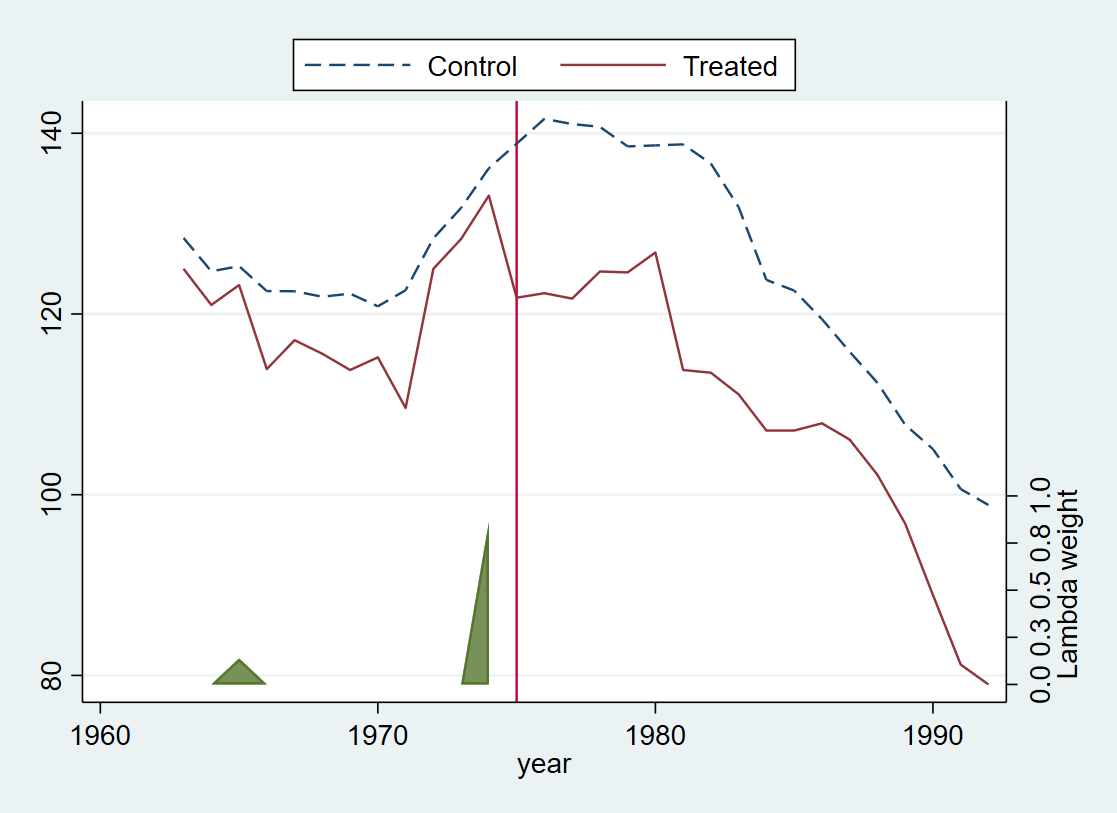

sdid_gtrends1976.png


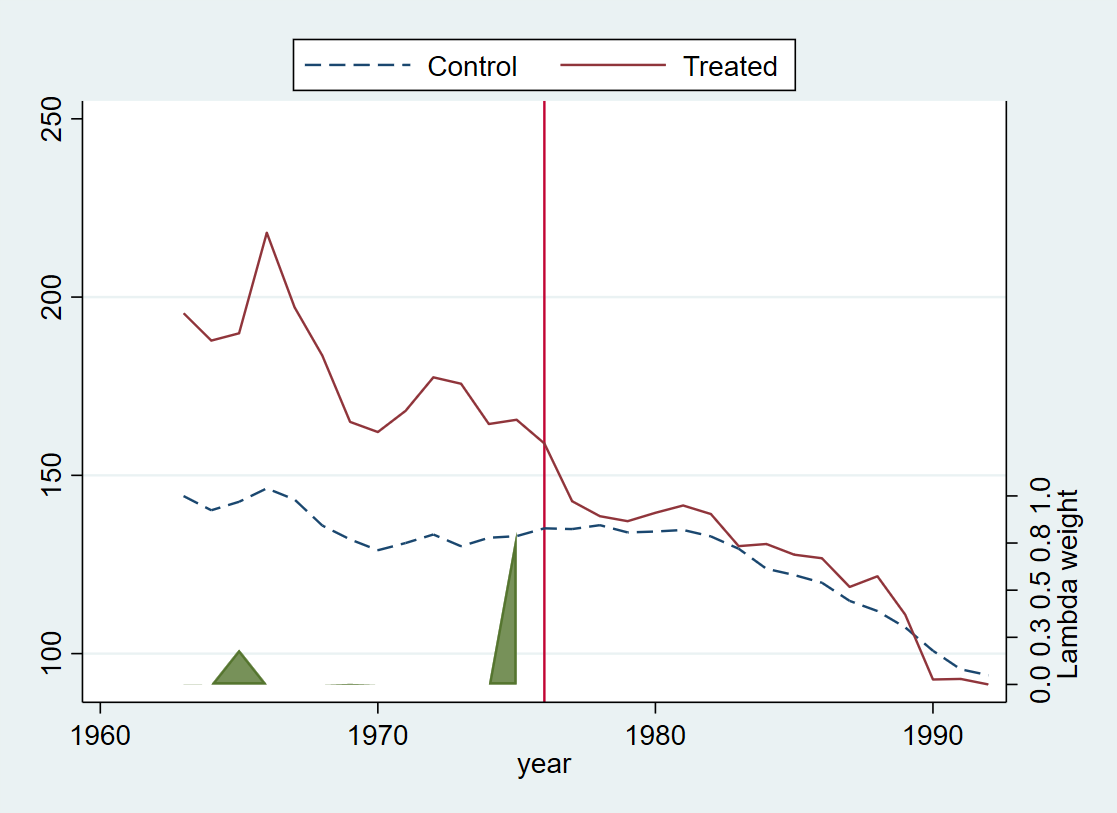

sdid_gtrends1978.png


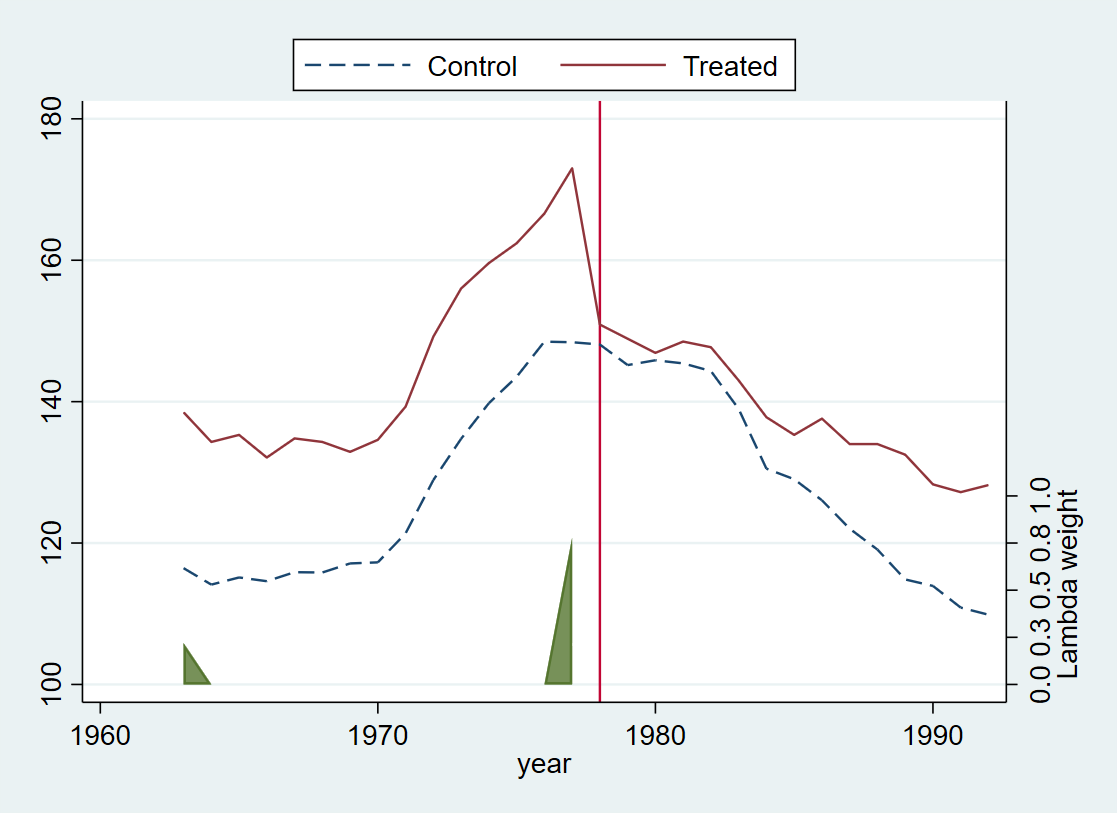

sdid_gtrends1979.png


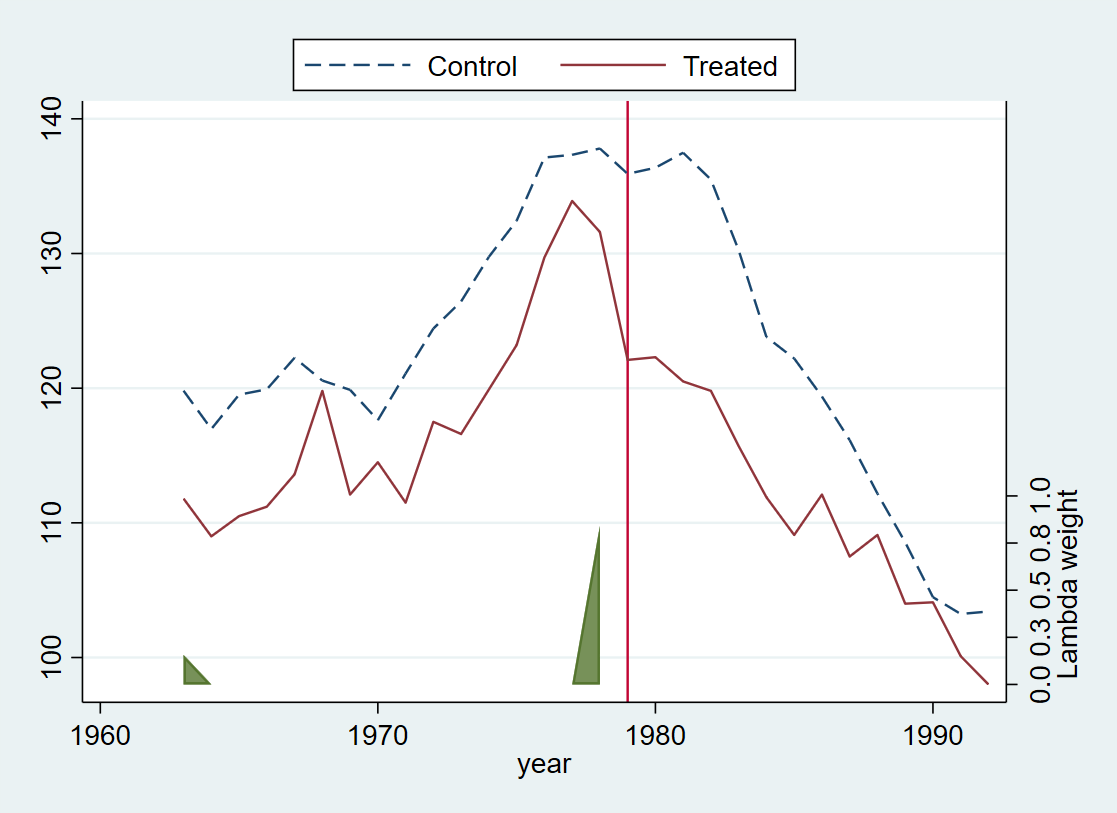

sdid_gtrends1981.png


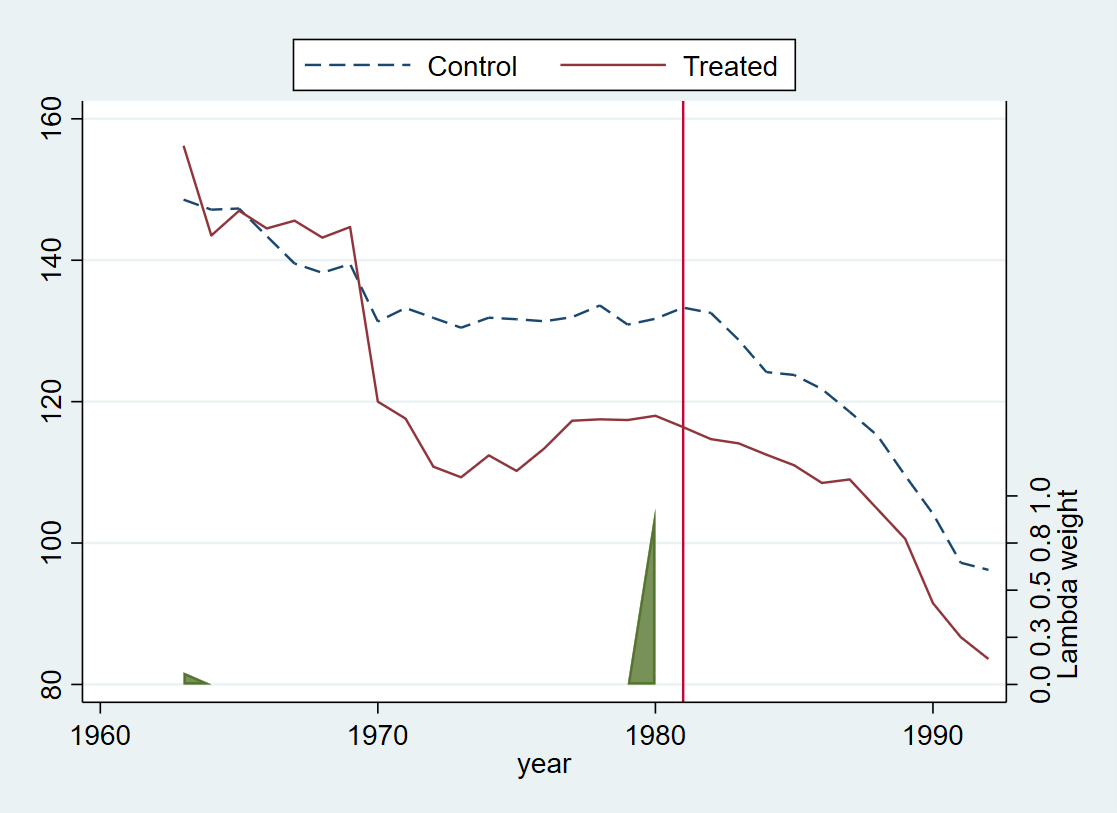

sdid_gtrends1983.png


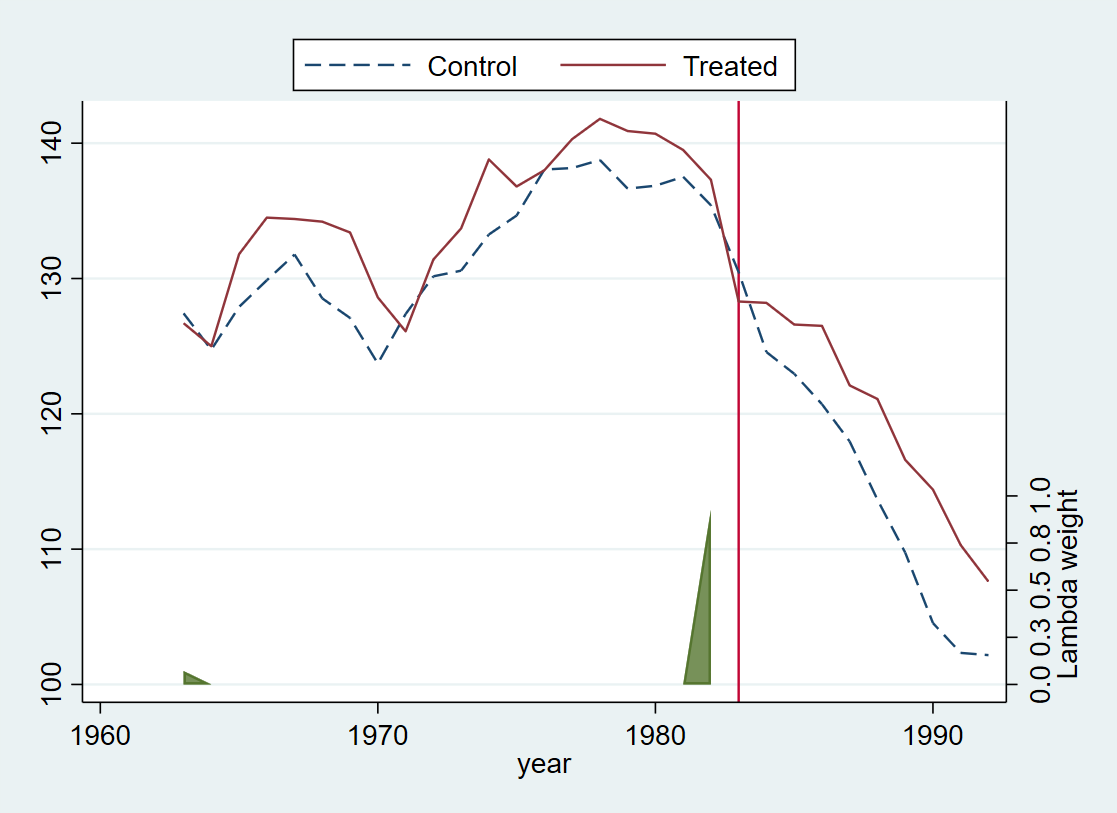

sdid_gtrends1986.png


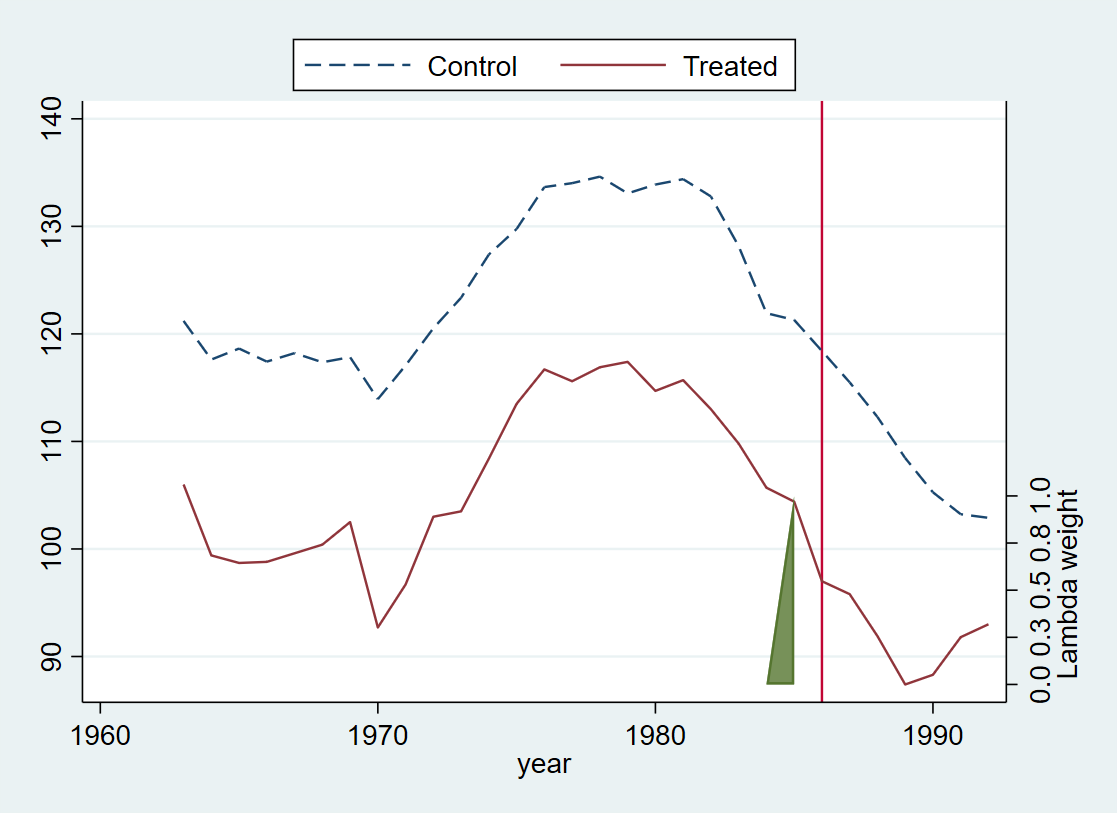

--- Pesos de unidades de control (7 graficos) ---
sdid_gweights1975.png


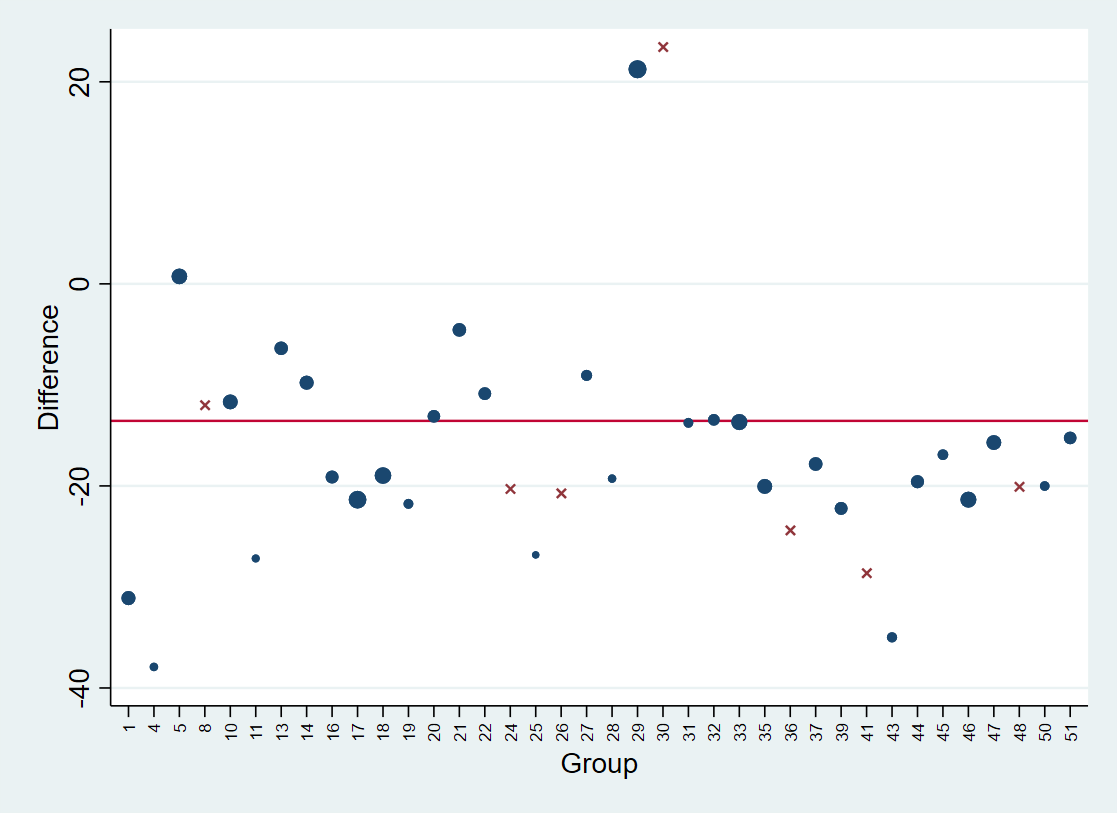

sdid_gweights1976.png


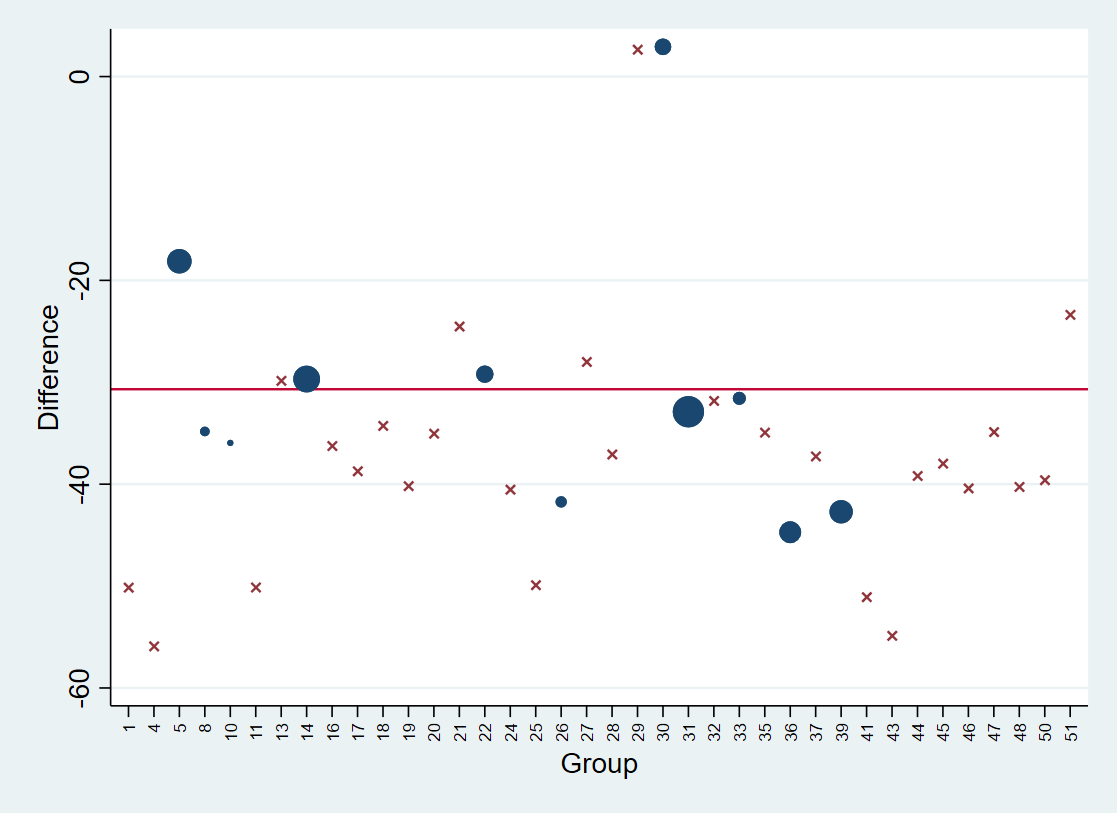

sdid_gweights1978.png


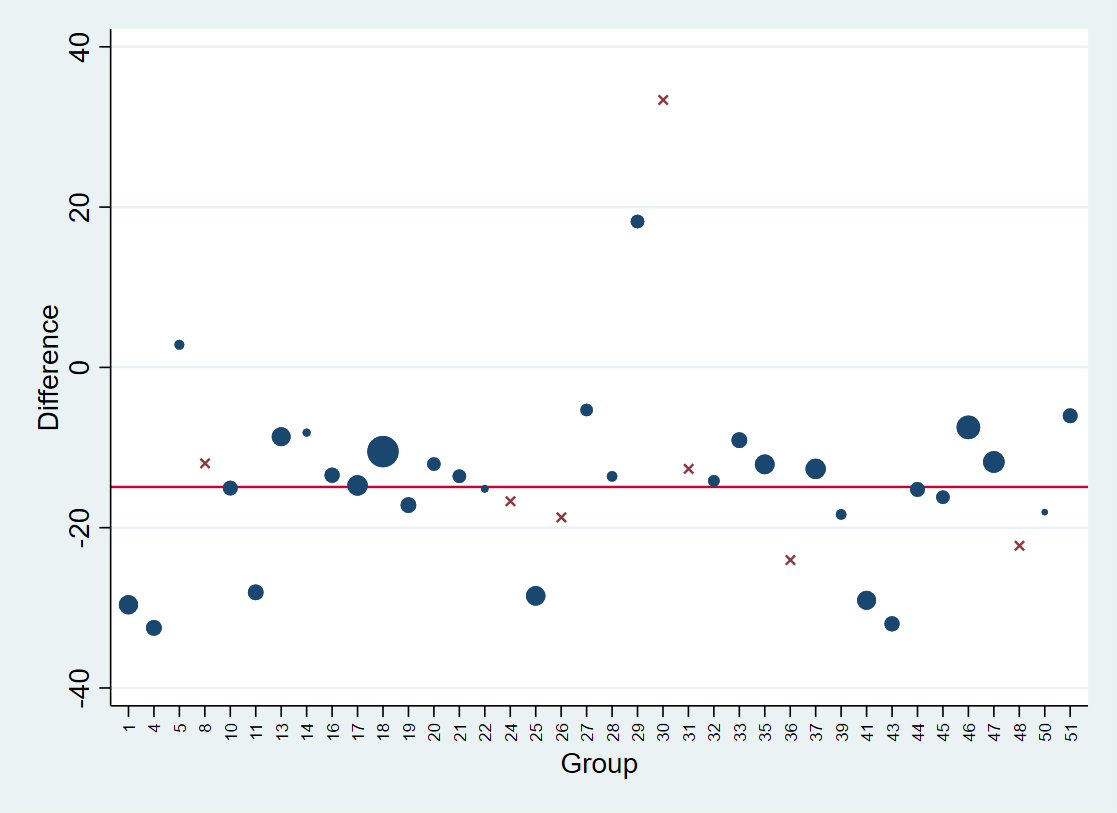

sdid_gweights1979.png


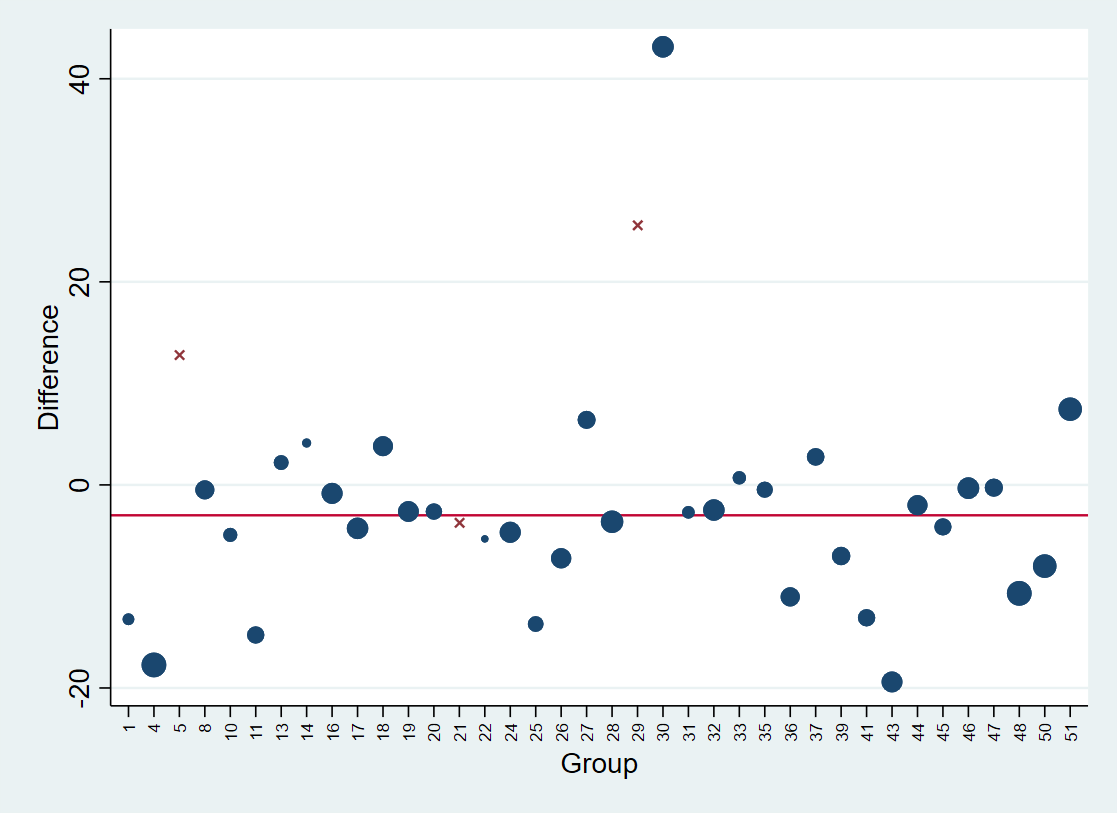

sdid_gweights1981.png


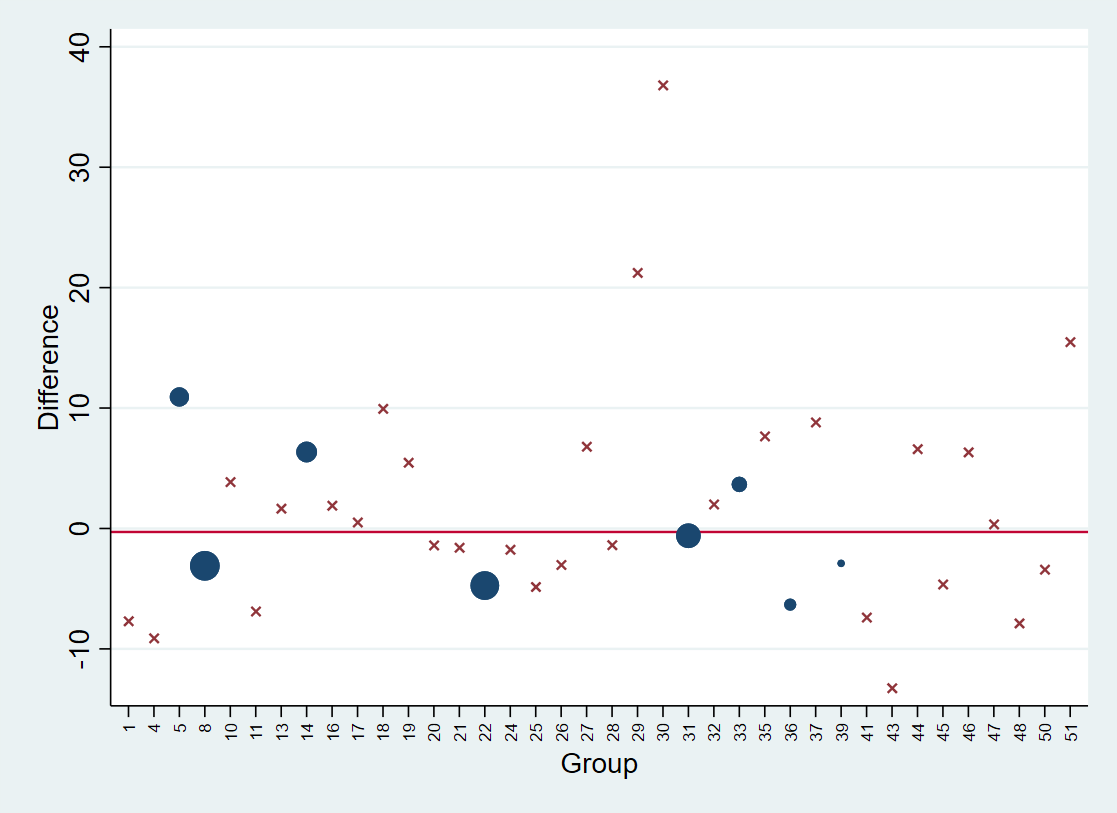

sdid_gweights1983.png


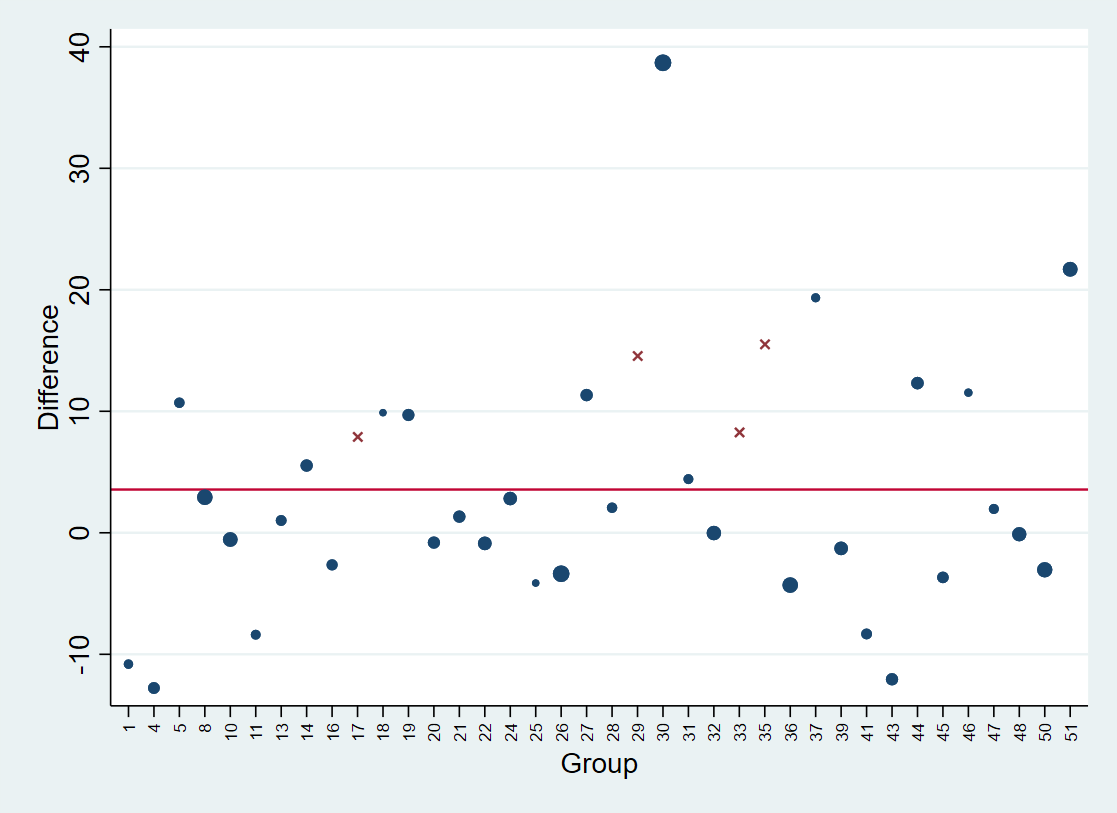

sdid_gweights1986.png


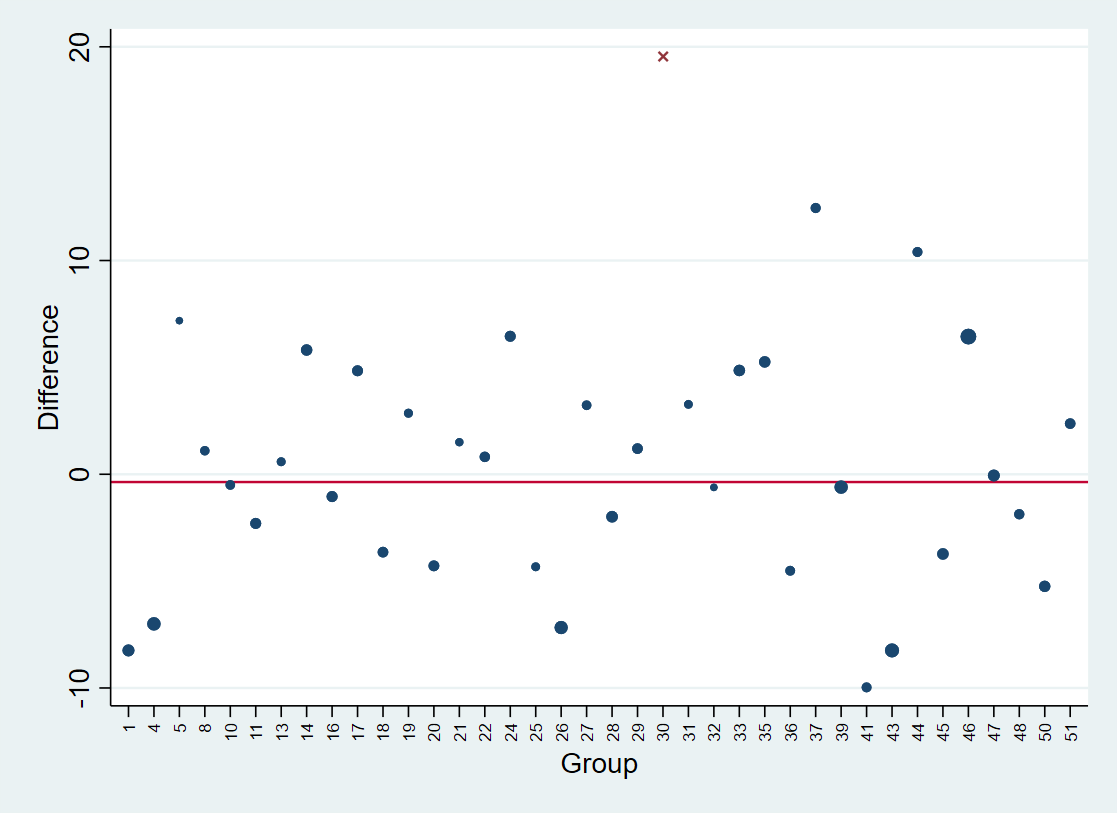

In [16]:
import glob

# Trayectorias: tratados vs control sintetico
trends = sorted(glob.glob(os.path.join(WORK_DIR, "sdid_gtrends*.png")))
print(f"--- Trayectorias ({len(trends)} graficos) ---")
for gf in trends:
    print(os.path.basename(gf))
    display(Image(gf))

# Pesos de unidades de control (omega)
weights_plots = sorted(glob.glob(os.path.join(WORK_DIR, "sdid_gweights*.png")))
print(f"--- Pesos de unidades de control ({len(weights_plots)} graficos) ---")
for gf in weights_plots:
    print(os.path.basename(gf))
    display(Image(gf))